# EDA
## 1. 데이터 로드 및 기본 구조 확인

In [ ]:
# 데이터 로드
import os
from pathlib import Path

import pandas as pd

# 패키지 경로 탐색 최적화 & 데이터 파일 경로
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
DATA = "/data/heart+disease/processed.cleveland.data"

# 데이터 상세 기록에 명시된 컬럼명(스키마)
HEART_DISEASE_SCHEMA = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

df = pd.read_csv(
    str(PROJECT_ROOT) + DATA, header=None, names=HEART_DISEASE_SCHEMA, na_values="?"
)

In [ ]:
# 기본 구조 확인
display(df.info())
display(df.head())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 2. 타깃 클래스 분포 분석 및 평가 지표 연계

In [ ]:
df["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [ ]:
# target 클래스 값을 이진화(target=0 정상 / =1 심장병)
df.loc[df["target"] > 1, "target"] = 1

In [7]:
df["target"].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

-> target 클래스의 데이터 불균형(54%: 46%)이 존재하므로 해당 부분에 대한 처리가 필요

## 3. 연속형 변수의 결측치 및 이상치 탐지

In [ ]:
# 결측값 탐지
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

■ age        | IQR 범위: [28.5, 80.5] | 이상치 개수: 0개
■ trestbps   | IQR 범위: [90.0, 170.0] | 이상치 개수: 9개
■ chol       | IQR 범위: [115.0, 371.0] | 이상치 개수: 5개
■ thalach    | IQR 범위: [84.8, 214.8] | 이상치 개수: 1개
■ oldpeak    | IQR 범위: [-2.4, 4.0] | 이상치 개수: 5개

■ 최소 하나 이상의 연속형 변수에서 이상치를 가진 총 샘플 수: 19개


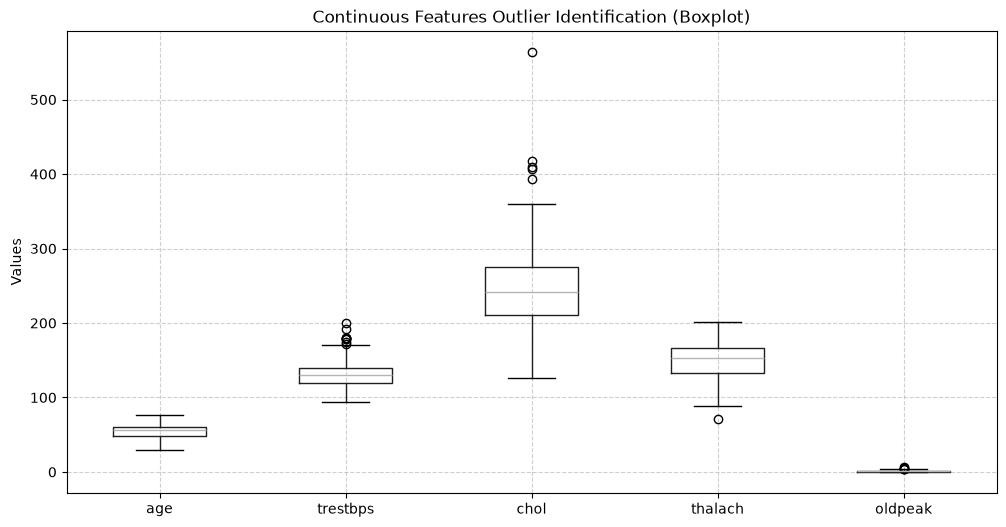

In [ ]:
# 이상치 탐지
import matplotlib.pyplot as plt

# 1. 수치형 변수 정의
NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak"]

outlier_indices = set()

for col in NUMERIC_FEATURES:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(
            f"* {col:<10} | IQR 범위: [{lower_bound:.1f}, {upper_bound:.1f}] | 이상치 개수: {len(outliers)}개"
        )
        outlier_indices.update(outliers.index)

print(
    f"\n> 최소 하나 이상의 연속형 변수에서 이상치를 가진 총 샘플 수: {len(outlier_indices)}개"
)

# 시각화 (Boxplot)
plt.figure(figsize=(12, 6))
df[NUMERIC_FEATURES].boxplot()
plt.title("Continuous Features Outlier Identification (Boxplot)")
plt.ylabel("Values")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### preprocessing pipeline
`preprocessing.py`에 구현

## EDA 요약
### 1. EDA가 알려준 사실 (Findings)

- 타깃 변수의 다중 클래스 분포: 원본 데이터의 심장병 진단 상태(`target`)가 0부터 4까지 5개 클래스로 분산되어 있으나, 예측 시스템의 본 목적은 심장병 발병 여부의 이진 분류임.

- 소량의 범주형 결측치 발견: 전체 303개 레코드 중 `ca`(형광투시 혈관 수)에서 4개, `thal`(심장 결함 여부)에서 2개로 총 6개(약 2%)의 결측치가 탐지됨.

- 임상적 이상치 존재: IQR(사분위수 범위) 기준 탐지 결과 `chol`(콜레스테롤), `trestbps`(휴식기 혈압), oldpeak 등 연속형 특성에서 19개의 극단적인 고값(이상치)이 식별됨.

- 파이프라인 유입 구조 취약성: 데이터 수집 및 병합 과정에서 무효한 중복 레코드나 전체 행이 결측치인 빈 컬럼(Empty Column)이 유입될 위험이 존재함.

### 2. 그에 따른 전처리 변경 사항 (Actions)

- 타깃 변수 이진화 (Binarization):
원본 타깃 값 0은 정상(0), 1, 2, 3, 4는 심장병 발병 고위험군(1)으로 `apply(lambda x: 1 if x > 0 else 0)` 연산을 적용해 이진 분류 목적에 맞게 스키마를 변경 통합함.

- 행 삭제 배제 및 특성별 분리 대치 (Imputation):
샘플 수 유실을 방지하기 위해 결측치 포함 행을 삭제하지 않고 전량 대치.
이상치에 의한 왜곡을 막기 위해 수치형 변수는 중앙값(Median)으로 대치하고, 범주형 변수(`ca`, `thal`)는 도메인 특성을 보존하기 위해 최빈값으로 대치함.

- IQR 기준 상하한선 클리핑 (Winsorization):
임상 데이터의 이상치는 질환의 핵심 신호이므로 행을 삭제하지 않고 보존하되, 특정 극단값이 선형 가중치나 거리 기반 모델을 왜곡하는 현상을 커스텀 변환기인 OutlierClipper를 파이프라인에 결합하여 학습 데이터셋에서 도출된 [Q1−1.5×IQR,Q3+1.5×IQR] 경계값으로 강제 클리핑 처리함으로써 방지함.

- 글로벌 데이터 클리닝 층 구축:
scikit-learn 파이프라인 전단에 중복 데이터를 제거하고 모든 값이 NaN인 빈 컬럼을 선제적으로 탈락시키는 clean_raw_data 방어 함수를 구현하여 데이터의 순도를 높임으로써 데이터 적합 과정 및 추론 시 발생할 수 있는 데이터 정렬 오류와 스키마 붕괴를 예방함